In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
import os

data_path = "PlantVillage"

classes = os.listdir(data_path)
print("Number of classes:", len(classes))
print(classes[:10])


Number of classes: 15
['Potato___Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Pepper__bell___Bacterial_spot', 'Potato___Late_blight']


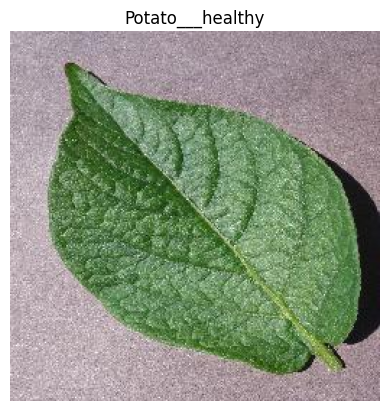

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_class = random.choice(classes)
sample_path = os.path.join(data_path, sample_class)
sample_image = random.choice(os.listdir(sample_path))

img = Image.open(os.path.join(sample_path, sample_image))

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

source_dir = "PlantVillage"
base_dir = "data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    images = os.listdir(class_path)

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, class_name, img))

In [ ]:
print("Train classes:", len(os.listdir(train_dir)))
print("Val classes:", len(os.listdir(val_dir)))

Train classes: 15
Val classes: 15


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


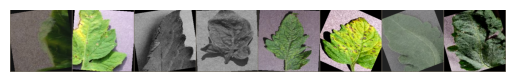

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision


def imshow(img):
    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
imshow(torchvision.utils.make_grid(images[:8]))

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

print(model)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)


Trainable parameters: 19215


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):

    best_acc = 0.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 20)

        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f"Training Loss: {epoch_loss:.4f}")


        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total
        print(f"Validation Accuracy: {val_acc:.4f}")


        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved!")

    print(f"\nBest Validation Accuracy: {best_acc:.4f}")

In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)


Epoch 1/5
--------------------
Training Loss: 1.2319
Validation Accuracy: 0.8597
Best model saved!

Epoch 2/5
--------------------
Training Loss: 0.8283
Validation Accuracy: 0.8856
Best model saved!

Epoch 3/5
--------------------
Training Loss: 0.7546
Validation Accuracy: 0.9001
Best model saved!

Epoch 4/5
--------------------
Training Loss: 0.7326
Validation Accuracy: 0.9023
Best model saved!

Epoch 5/5
--------------------
Training Loss: 0.7093
Validation Accuracy: 0.9066
Best model saved!

Best Validation Accuracy: 0.9066


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)


Epoch 1/5
--------------------
Training Loss: 0.6215
Validation Accuracy: 0.9301
Best model saved!

Epoch 2/5
--------------------
Training Loss: 0.5091
Validation Accuracy: 0.9519
Best model saved!

Epoch 3/5
--------------------
Training Loss: 0.4587
Validation Accuracy: 0.9562
Best model saved!

Epoch 4/5
--------------------
Training Loss: 0.4183
Validation Accuracy: 0.9618
Best model saved!

Epoch 5/5
--------------------
Training Loss: 0.3806
Validation Accuracy: 0.9659
Best model saved!

Best Validation Accuracy: 0.9659


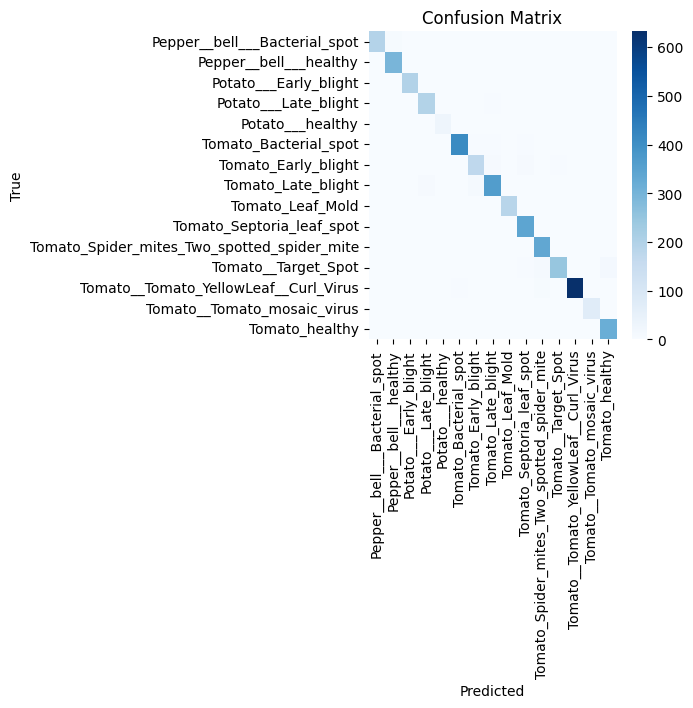

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
torch.save(model.state_dict(), "efficientnet_stage2.pth")

In [ ]:
!kaggle datasets download -d nirmalsankalana/plantdoc-dataset
!unzip plantdoc-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
 99% 891M/896M [00:03<00:00, 128MB/s]
100% 896M/896M [00:03<00:00, 253MB/s]
Archive:  plantdoc-dataset.zip
  inflating: file_renamer.py         
  inflating: folder_renamer.py       
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_1.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_10.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_2.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_3.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_4.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_5.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_6.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_7.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_8.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_9.jpg  
  inflating: test/Apple_leaf/test_Apple leaf_1.jpg  
  inflating: test/Apple_leaf/test_A

In [ ]:
print("PlantVillage classes:\n")
print(class_names)

print("\nPlantDoc classes:\n")
print(os.listdir("train"))

PlantVillage classes:

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

PlantDoc classes:

['grape_leaf_black_rot', 'Soyabean_leaf', 'Bell_pepper_leaf_spot', 'Corn_leaf_blight', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_yellow_virus', 'Corn_rust_leaf', 'grape_leaf', 'Tomato_mold_leaf', 'Tomato_leaf_late_blight', 'Corn_Gray_leaf_spot', 'Tomato_leaf', 'Raspberry_leaf', 'Tomato_leaf_mosaic_virus', 'Apple_rust_leaf', 'Potato_leaf_late_blight', 'Tomato_Early_blight_leaf', 'Blueberry_leaf', 'Tomato_Septoria_leaf_spot', 'Bell_pepper_leaf', 'Apple_Scab_Leaf', 'Potato_leaf_early_blight', 'Tomato_two_spotted_spider_mites_leaf', 'Cherry_leaf'

In [ ]:
mapping = {
    "Tomato_leaf_bacterial_spot": class_names.index("Tomato_Bacterial_spot"),
    "Tomato_Early_blight_leaf": class_names.index("Tomato_Early_blight"),
    "Tomato_leaf_late_blight": class_names.index("Tomato_Late_blight"),
    "Tomato_Septoria_leaf_spot": class_names.index("Tomato_Septoria_leaf_spot"),
    "Tomato_two_spotted_spider_mites_leaf": class_names.index("Tomato_Spider_mites_Two_spotted_spider_mite"),
    "Tomato_leaf_yellow_virus": class_names.index("Tomato__Tomato_YellowLeaf__Curl_Virus"),
    "Tomato_leaf_mosaic_virus": class_names.index("Tomato__Tomato_mosaic_virus"),
    "Tomato_mold_leaf": class_names.index("Tomato_Leaf_Mold"),
    "Potato_leaf_early_blight": class_names.index("Potato___Early_blight"),
    "Potato_leaf_late_blight": class_names.index("Potato___Late_blight"),
    "Bell_pepper_leaf_spot": class_names.index("Pepper__bell___Bacterial_spot")
}

print("Number of overlapping classes:", len(mapping))


Number of overlapping classes: 11


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from PIL import Image

class FilteredPlantDoc(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []

        for class_name in os.listdir(root):
            if class_name in mapping:
                class_path = os.path.join(root, class_name)
                for img_name in os.listdir(class_path):
                    self.samples.append((
                        os.path.join(class_path, img_name),
                        mapping[class_name]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
plantdoc_dataset = FilteredPlantDoc("train", transform=val_transform)

plantdoc_loader = DataLoader(
    plantdoc_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Filtered PlantDoc samples:", len(plantdoc_dataset))

Filtered PlantDoc samples: 1211


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in plantdoc_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

plantdoc_acc = correct / total
print("PlantDoc Accuracy without FT:", plantdoc_acc)

PlantDoc Accuracy without FT: 0.25681255161023947


In [ ]:
from torch.utils.data import random_split

total_size = len(plantdoc_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

plantdoc_train, plantdoc_val = random_split(
    plantdoc_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(plantdoc_train))
print("Val size:", len(plantdoc_val))

Train size: 968
Val size: 243


In [ ]:
plantdoc_full = FilteredPlantDoc("train", transform=None)

indices = list(range(len(plantdoc_full)))
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, random_state=42
)

class PlantDocSplit(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_path, label = self.base.samples[self.indices[idx]]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

plantdoc_train = PlantDocSplit(plantdoc_full, train_indices, train_transform)
plantdoc_val = PlantDocSplit(plantdoc_full, val_indices, val_transform)

plantdoc_train_loader = DataLoader(plantdoc_train, batch_size=32, shuffle=True)
plantdoc_val_loader = DataLoader(plantdoc_val, batch_size=32, shuffle=False)

In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
train_model(
    model,
    plantdoc_train_loader,
    plantdoc_val_loader,
    criterion,
    optimizer,
    epochs=5
)


Epoch 1/5
--------------------
Training Loss: 3.4366
Validation Accuracy: 0.3045
Best model saved!

Epoch 2/5
--------------------
Training Loss: 3.3105
Validation Accuracy: 0.3210
Best model saved!

Epoch 3/5
--------------------
Training Loss: 3.1338
Validation Accuracy: 0.3251
Best model saved!

Epoch 4/5
--------------------
Training Loss: 2.9312
Validation Accuracy: 0.3292
Best model saved!

Epoch 5/5
--------------------
Training Loss: 2.8315
Validation Accuracy: 0.3416
Best model saved!

Best Validation Accuracy: 0.3416


In [ ]:
overlap_classes = list(mapping.keys())
print(len(overlap_classes))

11


In [ ]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    11
)

model = model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [ ]:
new_mapping = {
    "Tomato_leaf_bacterial_spot": 0,
    "Tomato_Early_blight_leaf": 1,
    "Tomato_leaf_late_blight": 2,
    "Tomato_Septoria_leaf_spot": 3,
    "Tomato_two_spotted_spider_mites_leaf": 4,
    "Tomato_leaf_yellow_virus": 5,
    "Tomato_leaf_mosaic_virus": 6,
    "Tomato_mold_leaf": 7,
    "Potato_leaf_early_blight": 8,
    "Potato_leaf_late_blight": 9,
    "Bell_pepper_leaf_spot": 10
}

In [ ]:
if class_name in new_mapping:
    ...
    self.samples.append((
        os.path.join(class_path, img_name),
        new_mapping[class_name]
    ))

In [ ]:
plantdoc_full = FilteredPlantDoc("train", transform=None)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=False)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    15
)

model.load_state_dict(torch.load("efficientnet_stage2.pth"))
model = model.to(device)

print("PlantVillage model loaded.")

PlantVillage model loaded.


In [ ]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    11
)

model = model.to(device)

print("Classifier modified to 11 classes.")

Classifier modified to 11 classes.


In [ ]:
new_mapping = {
    "Tomato_leaf_bacterial_spot": 0,
    "Tomato_Early_blight_leaf": 1,
    "Tomato_leaf_late_blight": 2,
    "Tomato_Septoria_leaf_spot": 3,
    "Tomato_two_spotted_spider_mites_leaf": 4,
    "Tomato_leaf_yellow_virus": 5,
    "Tomato_leaf_mosaic_virus": 6,
    "Tomato_mold_leaf": 7,
    "Potato_leaf_early_blight": 8,
    "Potato_leaf_late_blight": 9,
    "Bell_pepper_leaf_spot": 10
}

In [ ]:
from torch.utils.data import Dataset, DataLoader

class FilteredPlantDoc(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []

        for class_name in os.listdir(root):
            if class_name in new_mapping:
                class_path = os.path.join(root, class_name)
                for img_name in os.listdir(class_path):
                    self.samples.append((
                        os.path.join(class_path, img_name),
                        new_mapping[class_name]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split

plantdoc_full = FilteredPlantDoc("train", transform=None)

labels = [label for _, label in plantdoc_full.samples]

print("Min label:", min(labels))
print("Max label:", max(labels))

Min label: 0
Max label: 10


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
plantdoc_full = FilteredPlantDoc("train", transform=None)

indices = list(range(len(plantdoc_full)))
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, random_state=42
)

class PlantDocSplit(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_path, label = self.base.samples[self.indices[idx]]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

plantdoc_train = PlantDocSplit(plantdoc_full, train_indices, train_transform)
plantdoc_val = PlantDocSplit(plantdoc_full, val_indices, val_transform)

plantdoc_train_loader = DataLoader(plantdoc_train, batch_size=32, shuffle=True)
plantdoc_val_loader = DataLoader(plantdoc_val, batch_size=32, shuffle=False)

print("Train size:", len(plantdoc_train))
print("Val size:", len(plantdoc_val))

Train size: 968
Val size: 243


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5
)

In [ ]:
train_model(
    model,
    plantdoc_train_loader,
    plantdoc_val_loader,
    criterion,
    optimizer,
    epochs=8
)


Epoch 1/8
--------------------
Training Loss: 2.3801
Validation Accuracy: 0.1481
Best model saved!

Epoch 2/8
--------------------
Training Loss: 2.2884
Validation Accuracy: 0.2798
Best model saved!

Epoch 3/8
--------------------
Training Loss: 2.1978
Validation Accuracy: 0.3663
Best model saved!

Epoch 4/8
--------------------
Training Loss: 2.0977
Validation Accuracy: 0.3992
Best model saved!

Epoch 5/8
--------------------
Training Loss: 1.9998
Validation Accuracy: 0.4074
Best model saved!

Epoch 6/8
--------------------
Training Loss: 1.9076
Validation Accuracy: 0.4609
Best model saved!

Epoch 7/8
--------------------
Training Loss: 1.8094
Validation Accuracy: 0.4815
Best model saved!

Epoch 8/8
--------------------
Training Loss: 1.7375
Validation Accuracy: 0.4938
Best model saved!

Best Validation Accuracy: 0.4938


In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM loaded")

SAM loaded


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

sample_path = plantdoc_full.samples[0][0]

image = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image_rgb)

print("Number of masks:", len(masks))

Number of masks: 34


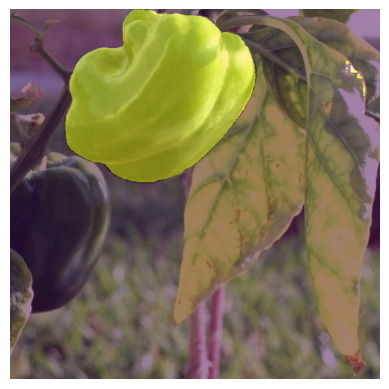

In [ ]:
largest_mask = max(masks, key=lambda x: x['area'])
segmentation = largest_mask['segmentation']

plt.imshow(image_rgb)
plt.imshow(segmentation, alpha=0.5)
plt.axis("off")
plt.show()

In [ ]:
def select_leaf_mask(image_rgb, masks):
    best_mask = None
    best_score = -1

    total_pixels = image_rgb.shape[0] * image_rgb.shape[1]

    for mask in masks:
        seg = mask['segmentation']
        area = mask['area']

        if area < 0.01 * total_pixels:
            continue

        masked_pixels = image_rgb[seg]

        if len(masked_pixels) == 0:
            continue

        r = masked_pixels[:, 0]
        g = masked_pixels[:, 1]
        b = masked_pixels[:, 2]

        green_score = np.mean(g - (r + b) / 2)

        area_score = area / total_pixels

        final_score = green_score * area_score

        if final_score > best_score:
            best_score = final_score
            best_mask = mask

    return best_mask

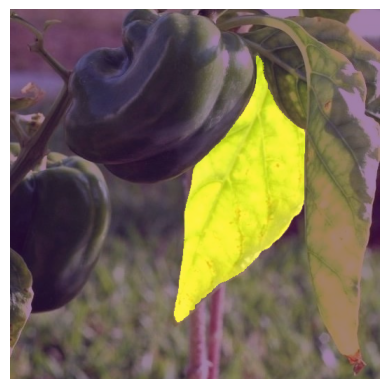

In [ ]:
leaf_mask = select_leaf_mask(image_rgb, masks)
segmentation = leaf_mask['segmentation']

plt.imshow(image_rgb)
plt.imshow(segmentation, alpha=0.5)
plt.axis("off")
plt.show()

In [ ]:
def crop_leaf(image_rgb, mask):
    seg = mask['segmentation']

    coords = np.column_stack(np.where(seg))

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = image_rgb[y_min:y_max, x_min:x_max]

    return cropped

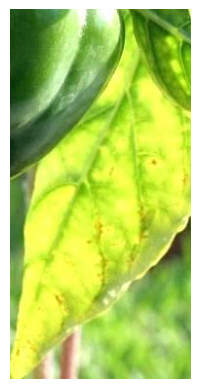

In [ ]:
leaf_mask = select_leaf_mask(image_rgb, masks)
cropped_leaf = crop_leaf(image_rgb, leaf_mask)

plt.imshow(cropped_leaf)
plt.axis("off")
plt.show()

In [ ]:
class SegmentedPlantDoc(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
     img_path, label = self.base.samples[self.indices[idx]]

     image = cv2.imread(img_path)
     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

     masks = mask_generator.generate(image_rgb)
     leaf_mask = select_leaf_mask(image_rgb, masks)

     if leaf_mask is not None:
        cropped = crop_leaf(image_rgb, leaf_mask)
     else:
        cropped = image_rgb

     image_pil = Image.fromarray(cropped)

     if self.transform:
        image_pil = self.transform(image_pil)

     return image_pil, label


In [ ]:
segmented_val_dataset = SegmentedPlantDoc(
    plantdoc_full,
    val_indices,
    val_transform
)

segmented_val_loader = DataLoader(
    segmented_val_dataset,
    batch_size=8,
    shuffle=False
)